In [1]:
import os 
os.chdir("..")
print(os.getcwd())
import gc
import torch

d:\pythonProject\IC Lab\Gait_analysis\pyskl


# 前處理示意圖


0: 384x640 1 person, 321.8ms
Speed: 6.1ms preprocess, 321.8ms inference, 157.6ms postprocess per image at shape (1, 3, 384, 640)


d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 39592 (\N{CJK UNIFIED IDEOGRAPH-9AA8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26550 (\N{CJK UNIFIED IDEOGRAPH-67B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


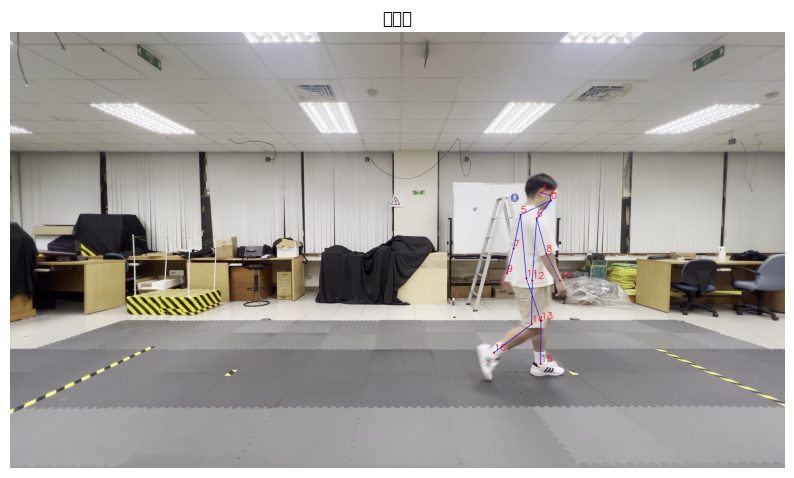

In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLO 模型載入
model = YOLO('yolo11x-pose.pt')
model.classes = [0]  # 假設只檢測人，請根據需求修改類別索引

# 定義骨架連接規則
inward = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 5), (12, 6),
    (9, 7), (7, 5), (10, 8), (8, 6), (5, 0), (6, 0),
    (1, 0), (3, 1), (2, 0), (4, 2)
]

def draw_keypoints_and_skeleton(frame, keypoints, connections):
    """
    在影像上繪製關節點和骨架。
    """
    keypoints = keypoints[0]  # 去掉第一維，取得 (17, 3) 的陣列
    keypoints_xy = keypoints[:, :2]  # 只提取 x, y 座標

    # 繪製關節點
    for i, (x, y) in enumerate(keypoints_xy):
        if x > 0 and y > 0:  # 只繪製有效點
            cv2.circle(frame, (int(x), int(y)), 5, (0, 0, 255), -1)  # 紅點
            cv2.putText(frame, str(i), (int(x), int(y)-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 2)

    # 繪製骨架
    for connection in connections:
        pt1, pt2 = connection
        if all(keypoints_xy[pt1]) and all(keypoints_xy[pt2]):  # 確保連接的點有效
            cv2.line(frame, tuple(map(int, keypoints_xy[pt1])), tuple(map(int, keypoints_xy[pt2])), (255, 0, 0), 2)  # 藍線

    return frame

def extract_and_process_frame(video_path, frame_idx=0):
    cap = cv2.VideoCapture(video_path)

    # 跳到指定的 frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()

    if not ret:
        print(f"無法讀取第 {frame_idx} 幀。")
        return

    # YOLO 推論
    results = model(frame)
    keypoints = results[0].keypoints.data.cpu().numpy()

    # 假設 keypoints 是 17 個點的(x, y)，這裡需要更改為你的 YOLO 模型提供的格式
    
    keypoints = keypoints.astype(int)  # 轉為整數像素座標

    # 標記關節點
    frame_with_keypoints = draw_keypoints_and_skeleton(frame.copy(), keypoints, inward)

    # 顯示骨架圖
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(frame_with_keypoints, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("骨架圖")
    plt.show()

    cap.release()
    return keypoints, frame

# 執行程式
video_path = r"40_sagittal_normal_01.MOV"
keypoints, frame = extract_and_process_frame(video_path, frame_idx=100)


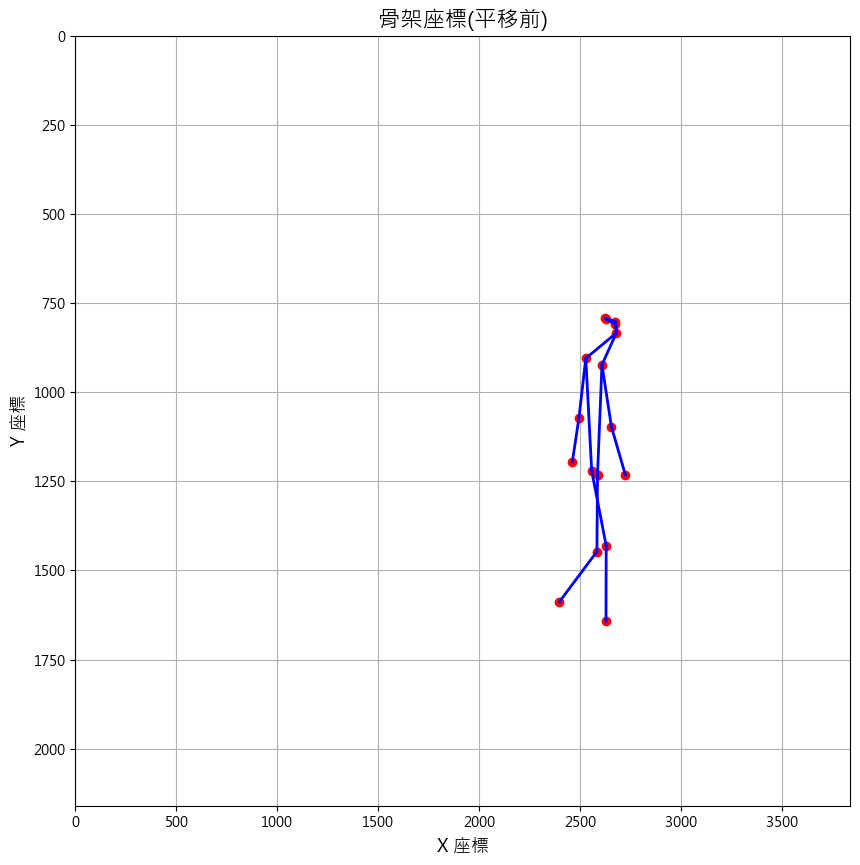

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 設定支持中文的字體
rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 使用微軟正黑體（適用於 Windows）
rcParams['axes.unicode_minus'] = False  # 確保負號正常顯示

inward = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 5), (12, 6),
    (9, 7), (7, 5), (10, 8), (8, 6), (5, 0), (6, 0),
    (1, 0), (3, 1), (2, 0), (4, 2)
]
def draw_keypoints_and_skeleton_with_axes(keypoints, connections, xlim=(-500, 500), ylim=(-500, 500), ax=None, title='骨架座標(平移前)'):
    """
    在空白畫布上繪製關節點和骨架，並顯示座標軸。
    """
    keypoints = keypoints[0]  # 去掉第一維，取得 (17, 3) 的陣列
    keypoints_xy = keypoints[:, :2]  # 只提取 x, y 座標

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # 設置畫布大小（與 frame_size 相同）
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[1], ylim[0])  # 注意 Matplotlib 的 y 軸是向下為負，需要反轉

    # 繪製關節點
    for i, (x, y) in enumerate(keypoints_xy):
        ax.plot(x, y, 'ro')  # 紅點
        # ax.text(x, y - 10, str(i), color="green", fontsize=10, ha='center')  # 標記 index

    # 繪製骨架
    for connection in connections:
        pt1, pt2 = connection
        if all(keypoints_xy[pt1]) and all(keypoints_xy[pt2]):  # 確保連接的點有效
            x_coords = [keypoints_xy[pt1][0], keypoints_xy[pt2][0]]
            y_coords = [keypoints_xy[pt1][1], keypoints_xy[pt2][1]]
            ax.plot(x_coords, y_coords, 'b-', linewidth=2)  # 藍線

    # 添加座標軸標籤，並設定字體大小為 13
    ax.set_xlabel("X 座標", fontsize=13)
    ax.set_ylabel("Y 座標", fontsize=13)

    # 添加標題
    ax.set_title(title, fontsize=16)
    ax.grid(True)
    # 顯示骨架圖

    
    if ax is None:
        plt.title("骨架座標(平移前)")
        plt.grid(True)
        plt.show()
    # 不在函數中使用 plt.show()，這樣可以讓圖像被保存而不顯示

    # 無需返回 ax 和 fig，因為它們已經在外部被修改


# 測試繪製在空白畫布上並添加座標軸
keypoints[0][1] = np.array([2676, 803, 0])
keypoints[0][3] = np.array([2625, 792, 0])

# 假設 frame 的大小是 (1920, 1080)
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(0,3840), ylim=(0, 2160))



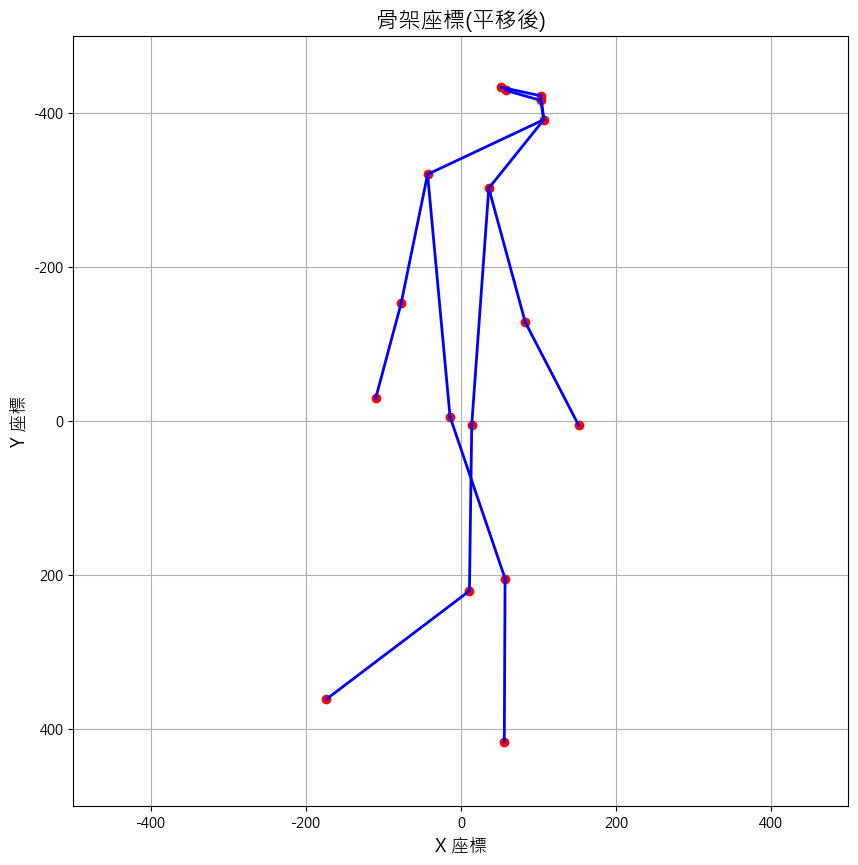

In [4]:
def translate_keypoints_to_origin(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移，使髖關節中心位於 (0, 0)。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 平移後的 keypoints。
    """
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算髖關節中心
    left_hip = keypoints_xy[left_hip_idx]
    right_hip = keypoints_xy[right_hip_idx]
    hip_center = (left_hip + right_hip) / 2

    # 平移 keypoints
    translated_keypoints = keypoints_xy - hip_center

    # 打包回原始格式
    keypoints[:, :2] = translated_keypoints  # 更新平移後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)

keypoints = translate_keypoints_to_origin(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-500, 500), ylim=(-500, 500), title='骨架座標(平移後)')



正規化後的 keypoints:
[[[    0.63529    0.049412           0]
  [    0.63059    0.012941           0]
  [    0.63059        0.02           0]
  [    0.57059           0           0]
  [    0.57765   0.0047059           0]
  [    0.45882     0.13294           0]
  [    0.55176     0.15412           0]
  [    0.41882     0.32941           0]
  [    0.60706     0.35882           0]
  [       0.38     0.47529           0]
  [    0.68824     0.51647           0]
  [    0.49294     0.50353           0]
  [    0.52588     0.51529           0]
  [    0.57647     0.75059           0]
  [    0.52235     0.76941           0]
  [    0.57529           1           0]
  [    0.30471     0.93529           0]]]


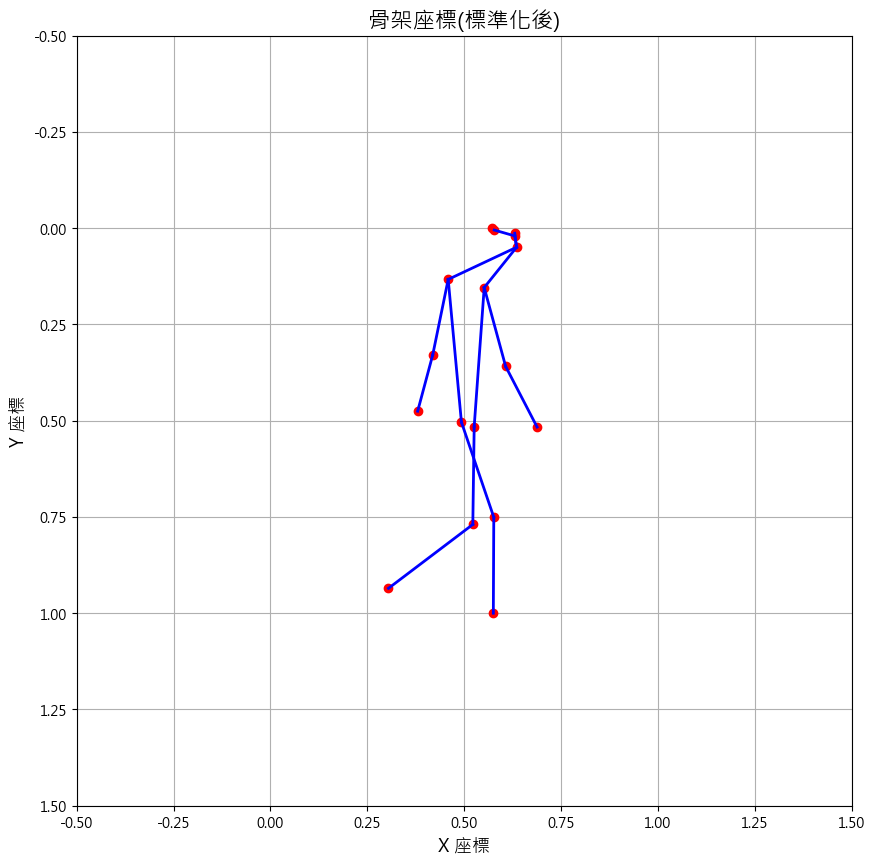

In [5]:
# 正規化後
def normalize_keypoints(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移到髖關節中心 (0, 0)，並對 x 和 y 座標進行正規化。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 正規化後的 keypoints。
    """
    keypoints = keypoints.astype(np.float32)  # 確保 keypoints 是浮點數型別
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算 y_max 和 y_min
    y_max = np.max(keypoints_xy[:, 1])
    y_min = np.min(keypoints_xy[:, 1])
    scale_factor = y_max - y_min if y_max != y_min else 1  # 避免除以零

    # 正規化 keypoints
    normalized_keypoints = np.zeros_like(keypoints_xy, dtype=np.float32)  # 明確設定為浮點型別
    normalized_keypoints[:, 0] = (keypoints_xy[:, 0] - y_min) / scale_factor
    normalized_keypoints[:, 1] = (keypoints_xy[:, 1] - y_min) / scale_factor

    # 打包回原始格式
    keypoints[:, :2] = normalized_keypoints  # 更新正規化後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)

# 使用測試數據進行正規化
keypoints = normalize_keypoints(keypoints)
print("正規化後的 keypoints:")
print(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5),title='骨架座標(標準化後)')



正規化後的 keypoints:
[[[    0.86196    0.049412           0]
  [    0.84969    0.012941           0]
  [    0.84969        0.02           0]
  [    0.69325           0           0]
  [    0.71166   0.0047059           0]
  [    0.40184     0.13294           0]
  [    0.64417     0.15412           0]
  [    0.29755     0.32941           0]
  [    0.78834     0.35882           0]
  [    0.19632     0.47529           0]
  [          1     0.51647           0]
  [     0.4908     0.50353           0]
  [    0.57669     0.51529           0]
  [    0.70859     0.75059           0]
  [    0.56748     0.76941           0]
  [    0.70552           1           0]
  [          0     0.93529           0]]]


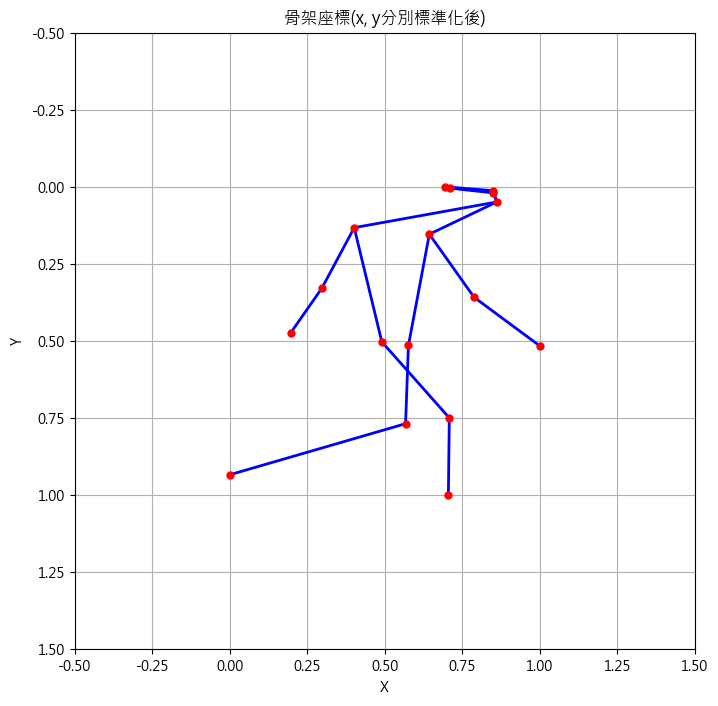

In [6]:
# 錯誤正規化後
def wrong_normalize_keypoints(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移到髖關節中心 (0, 0)，並對 x 和 y 座標進行正規化。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 正規化後的 keypoints。
    """
    keypoints = keypoints.astype(np.float32)  # 確保 keypoints 是浮點數型別
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算 y_max 和 y_min
    y_max = np.max(keypoints_xy[:, 1])
    y_min = np.min(keypoints_xy[:, 1])
    x_max = np.max(keypoints_xy[:, 0])
    x_min = np.min(keypoints_xy[:, 0])
    scale_factor_x = x_max - x_min if x_max != x_min else 1  # 避免除以零
    scale_factor_y = y_max - y_min if y_max != y_min else 1  # 避免除以零
    # 正規化 keypoints
    normalized_keypoints = np.zeros_like(keypoints_xy, dtype=np.float32)  # 明確設定為浮點型別
    normalized_keypoints[:, 0] = (keypoints_xy[:, 0] - x_min) / scale_factor_x
    normalized_keypoints[:, 1] = (keypoints_xy[:, 1] - y_min) / scale_factor_y

    # 打包回原始格式
    keypoints[:, :2] = normalized_keypoints  # 更新正規化後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)



def find_unconnected_keypoints(keypoints, connections):
    num_points = keypoints.shape[1]
    all_indices = set(range(num_points))
    connected = set()
    for a, b in connections:
        connected.add(a)
        connected.add(b)
    return all_indices - connected
    
def draw_keypoints_and_skeleton_with_axes(keypoints, connections, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), ax=None, title='Skeleton'):
    """
    繪製關鍵點與骨架線，並標示未連接點
    """
    keypoints = keypoints[0]  # (1, 17, 3) -> (17, 3)
    keypoints_xy = keypoints[:, :2]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlim(xlim)
    ax.set_ylim(ylim[1], ylim[0])  # 反轉 Y 軸
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True)

    # 畫線
    for a, b in connections:
        if not np.any(np.isnan(keypoints_xy[a])) and not np.any(np.isnan(keypoints_xy[b])):
            x_vals = [keypoints_xy[a][0], keypoints_xy[b][0]]
            y_vals = [keypoints_xy[a][1], keypoints_xy[b][1]]
            ax.plot(x_vals, y_vals, 'b-', linewidth=2)

    # 畫點
    for i, (x, y) in enumerate(keypoints_xy):
        ax.plot(x, y, 'ro', markersize=5)

    # 標示未連線點
    unconnected = find_unconnected_keypoints(keypoints[np.newaxis, :], connections)
    for idx in unconnected:
        x, y = keypoints_xy[idx]
        ax.scatter(x, y, s=150, color='red', edgecolors='black', zorder=5)
        ax.text(x + 0.02, y - 0.02, str(idx), fontsize=12, color='black')

    if ax is None:
        plt.show()

# 使用測試數據進行正規化
keypoints = wrong_normalize_keypoints(keypoints)
print("正規化後的 keypoints:")
print(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), title='骨架座標(x, y分別標準化後)')

# 資料集總覽

C:\Users\User\AppData\Local\Temp\ipykernel_32008\2009800173.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=height_data, x='Gender', y='Height', palette=['#3498db', '#e67e22'], ax=axs[1, 0])
C:\Users\User\AppData\Local\Temp\ipykernel_32008\2009800173.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weight_data, x='Gender', y='Weight', palette=['#3498db', '#e67e22'], ax=axs[1, 1])


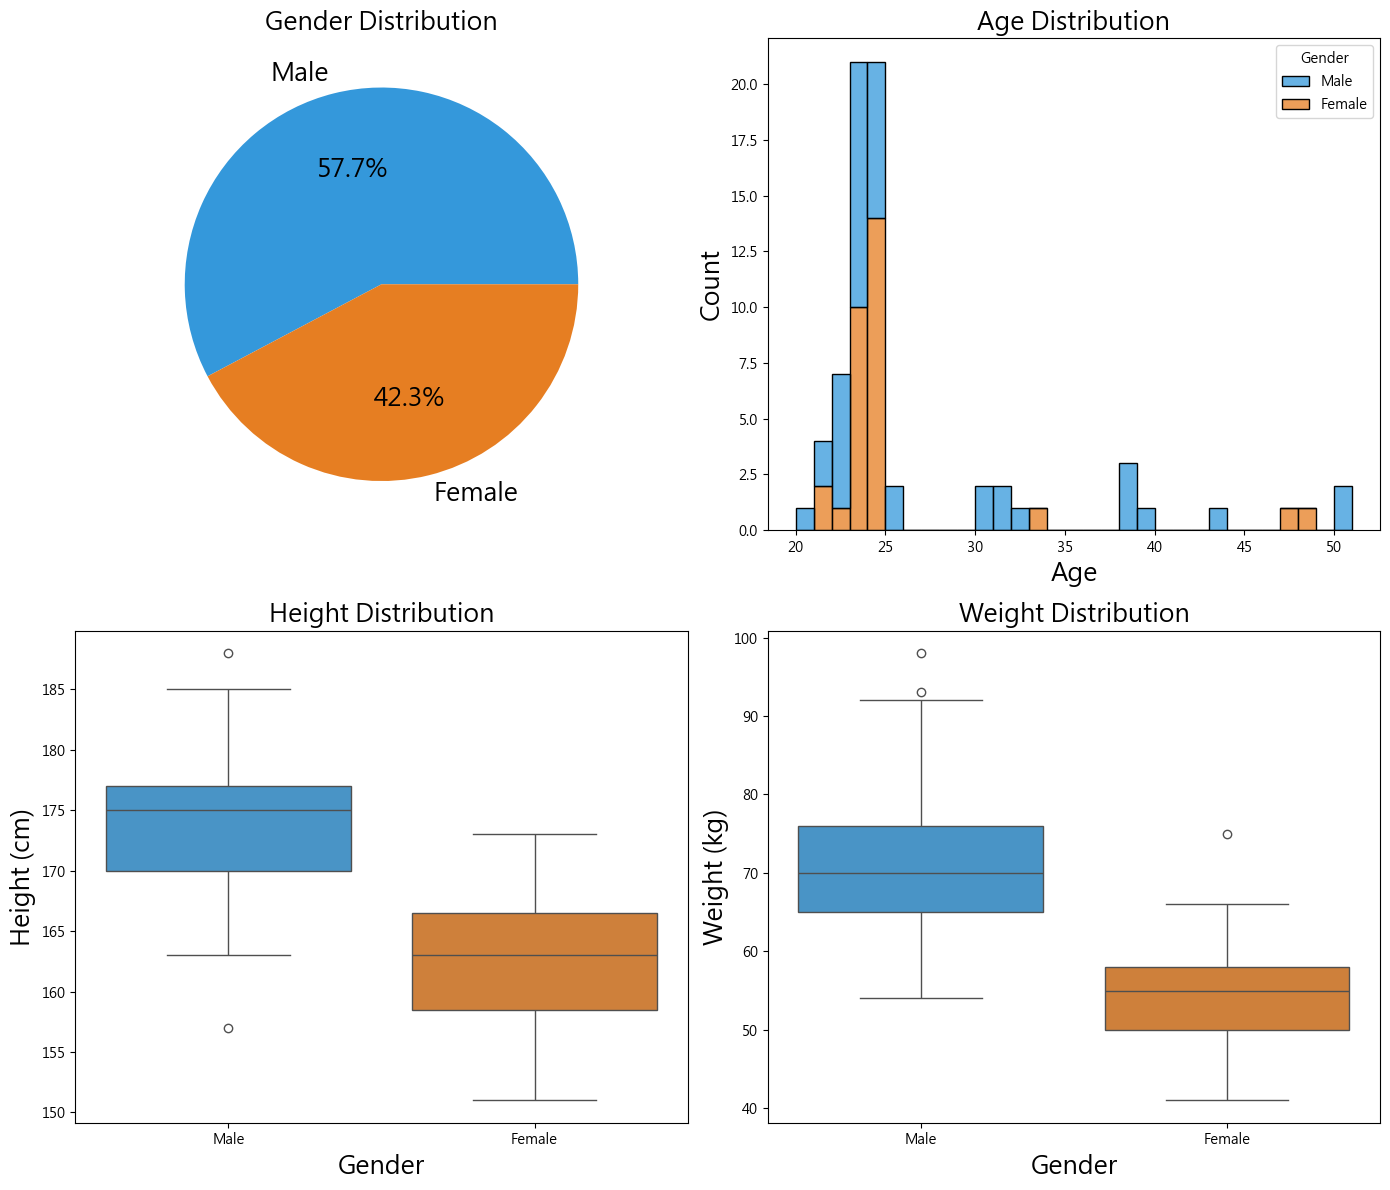

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
file_path = r"data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)

# Step 2: Rename columns to English
df = df.rename(columns={
    "性別": "Gender",
    "年齡(歲)": "Age",
    "身高(cm)": "Height",
    "體重(kg)": "Weight"
})

# Convert gender values from Chinese to English
df['Gender'] = df['Gender'].map({'男': 'Male', '女': 'Female'})

# Step 3: Prepare the data
gender_counts = df['Gender'].value_counts()
height_data = df[['Gender', 'Height']]
weight_data = df[['Gender', 'Weight']]

# Step 4: Create visualizations
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Gender distribution (pie chart)
axs[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#3498db', '#e67e22'], textprops={'fontsize': 18})
axs[0, 0].set_title('Gender Distribution', fontsize=18)

# Plot 2: Age distribution by gender (no binning, binwidth=1)
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack',
             palette=['#3498db', '#e67e22'], ax=axs[0, 1], binwidth=1)
axs[0, 1].set_title('Age Distribution', fontsize=18)
axs[0, 1].set_xlabel('Age', fontsize=18)
axs[0, 1].set_ylabel('Count', fontsize=18)

# Plot 3: Height distribution (box plot by gender)
sns.boxplot(data=height_data, x='Gender', y='Height', palette=['#3498db', '#e67e22'], ax=axs[1, 0])
axs[1, 0].set_title('Height Distribution', fontsize=18)
axs[1, 0].set_xlabel('Gender', fontsize=18)
axs[1, 0].set_ylabel('Height (cm)', fontsize=18)

# Plot 4: Weight distribution (box plot by gender)
sns.boxplot(data=weight_data, x='Gender', y='Weight', palette=['#3498db', '#e67e22'], ax=axs[1, 1])
axs[1, 1].set_title('Weight Distribution', fontsize=18)
axs[1, 1].set_xlabel('Gender', fontsize=18)
axs[1, 1].set_ylabel('Weight (kg)', fontsize=18)

# Adjust layout
plt.tight_layout()
plt.show()



各類別樣本數量：
Cluster 0: 59 人
Cluster 1: 12 人


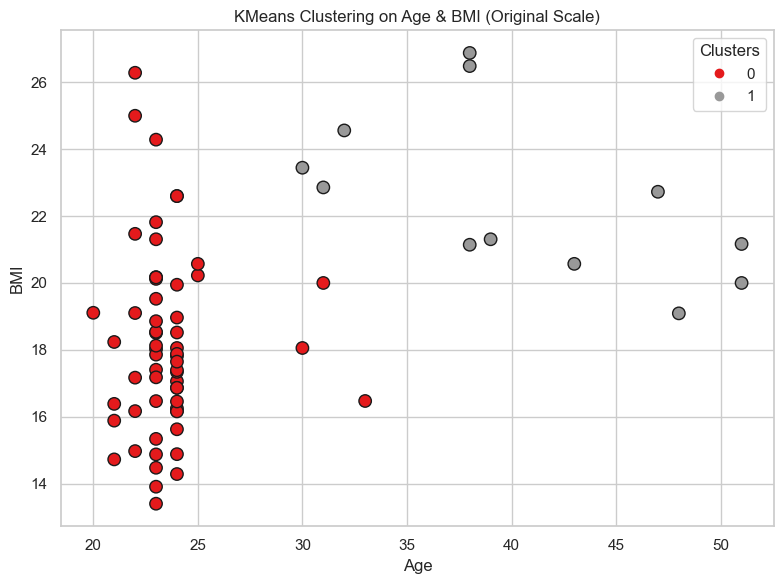

C:\Users\User\AppData\Local\Temp\ipykernel_32008\3859237509.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_32008\3859237509.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Cluster 0', 'Cluster 1'])  # 視覺顯示對應順序
C:\Users\User\AppData\Local\Temp\ipykernel_32008\3859237509.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_32008\3859237509.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_

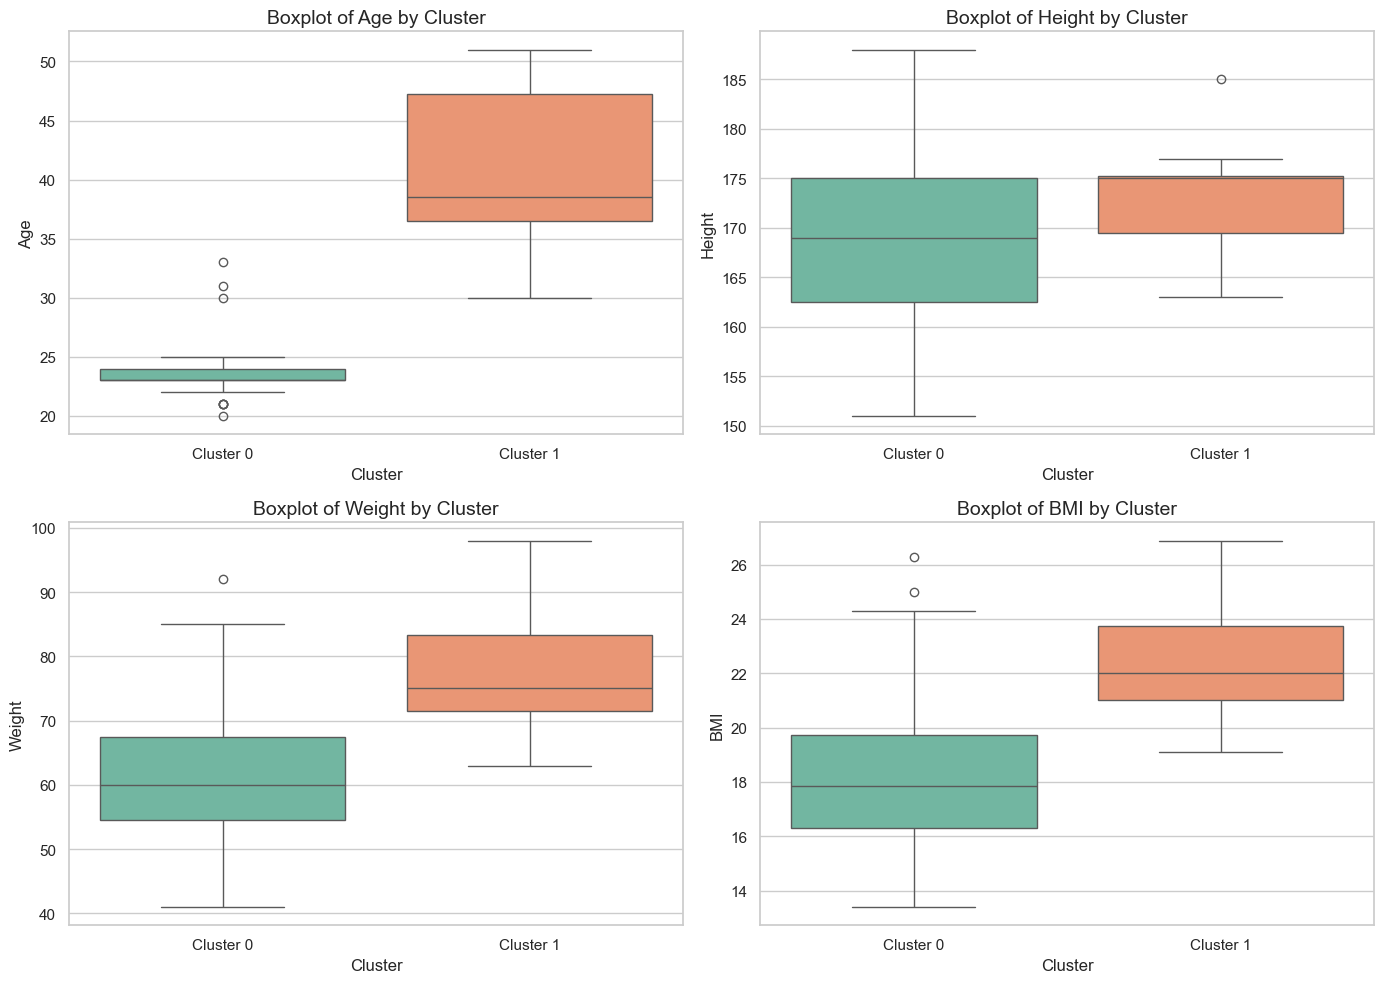

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 讀取資料
file_path = r"data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})

# 僅取用「年齡」與「BMI」，並移除缺失值
features = df[['年齡(歲)', 'BMI']].dropna()

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# KMeans 分群（2 群）
kmeans = KMeans(n_clusters=2, random_state=42, init='k-means++')
clusters = kmeans.fit_predict(X_scaled)

# 建立分群結果 DataFrame
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters
df_cleaned['Cluster'] = df_cleaned['Cluster'].astype(str)

# 顯示各群的樣本數
cluster_counts = df_cleaned['Cluster'].value_counts().sort_index()
print("\n各類別樣本數量：")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} 人")



# ✅ 散佈圖（原始年齡 vs. BMI 單位）
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features['年齡(歲)'], features['BMI'],
    c=clusters, cmap='Set1', edgecolors='k', s=80
)
plt.title('KMeans Clustering on Age & BMI (Original Scale)')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()


# 設定 Seaborn 樣式
sns.set(style="whitegrid")

# 確保 Cluster 是字串，利於分組
df_cleaned["Cluster"] = df_cleaned["Cluster"].astype(str)

# 欲繪製的欄位與標題
variables = ["年齡(歲)", "身高(cm)", "體重(kg)", "BMI"]
titles = ["Age", "Height", "Weight", "BMI"]

# 建立子圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 繪圖
for i, (var, title) in enumerate(zip(variables, titles)):
    sns.boxplot(
        data=df_cleaned,
        x="Cluster",
        y=var,
        ax=axes[i],
        palette="Set2",
        order=["0", "1"]  # 這行控制順序：左邊是 1 → 右邊是 0
    )
    axes[i].set_title(f"Boxplot of {title} by Cluster", fontsize=14)
    axes[i].set_xlabel("Cluster", fontsize=12)
    axes[i].set_ylabel(title, fontsize=12)
    axes[i].set_xticklabels(['Cluster 0', 'Cluster 1'])  # 視覺顯示對應順序

plt.tight_layout()
plt.show()


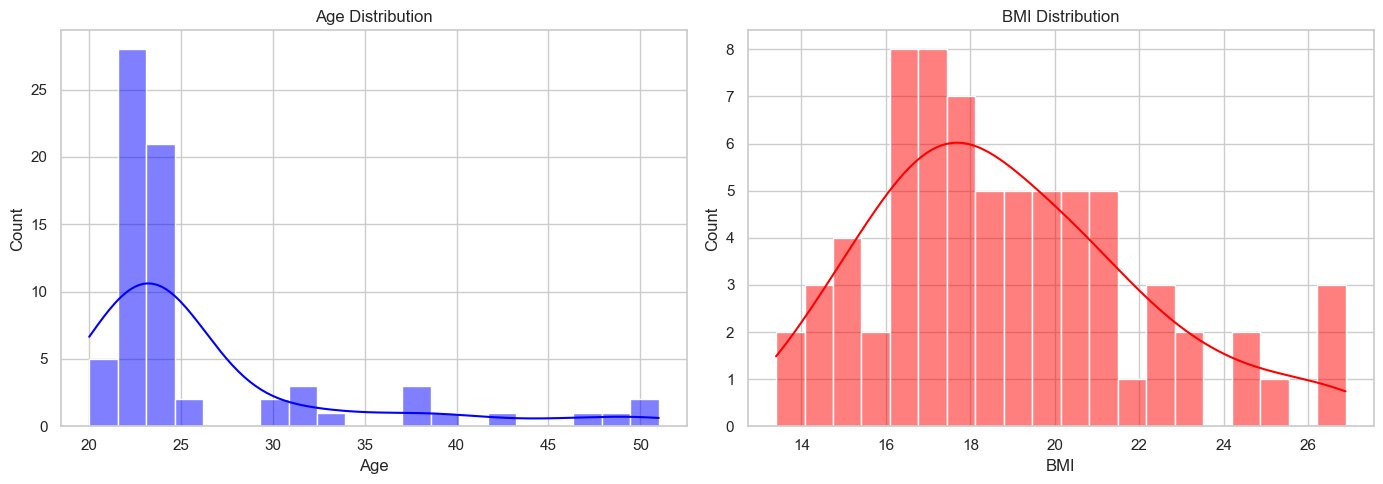

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
file_path = r"data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)

# 欄位名稱轉英文
df = df.rename(columns={
    '性別': 'Gender',
    '年齡(歲)': 'Age',
    'BMI': 'BMI'
})

# 性別轉換為數值 (optional)
df['Gender'] = df['Gender'].map({'男': 0, '女': 1})

# 選擇要繪圖的特徵
features = df[['Age', 'BMI']].dropna()

# 設定 Seaborn 樣式（不用中文字體）
sns.set(style="whitegrid")

# 繪製分布圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(features['Age'], kde=True, bins=20, ax=axes[0], color="blue")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.histplot(features['BMI'], kde=True, bins=20, ax=axes[1], color="red")
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


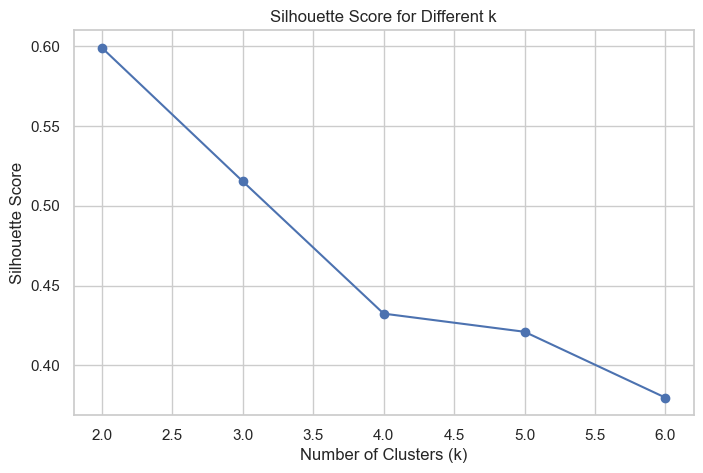

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)  # 你用 MinMaxScaler 或 StandardScaler 的結果
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# 繪圖
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

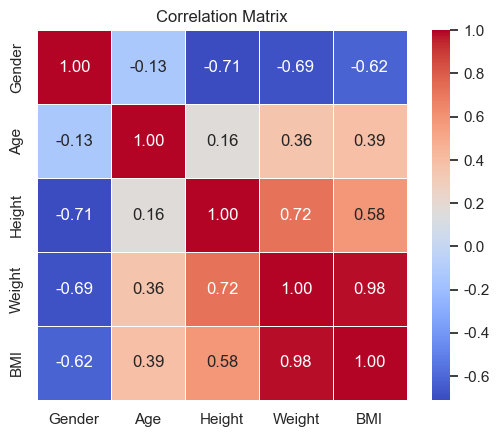

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Avoid minus sign display issues
plt.rcParams['axes.unicode_minus'] = False

# Example: rename columns from Chinese to English if needed
df = df.rename(columns={
    "性別": "Gender",
    "年齡(歲)": "Age",
    "身高(cm)": "Height",
    "體重(kg)": "Weight",
    "BMI": "BMI"
})

# Compute correlation matrix
corr_matrix = df[['Gender', 'Age', 'Height', 'Weight', 'BMI']].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Matrix")
plt.show()

# Confusion Matrix

In [12]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ✅ Step 1: 讀取 CSV 檔案
csv_path = r"colab\merged_preds.csv"  # 這檔案是融合各跑30次的結果
final_df = pd.read_csv(csv_path)

In [13]:
# 可以自訂變更
custom_labels = ["Class 1", "Class 2", "Class 3", "Class 4"]

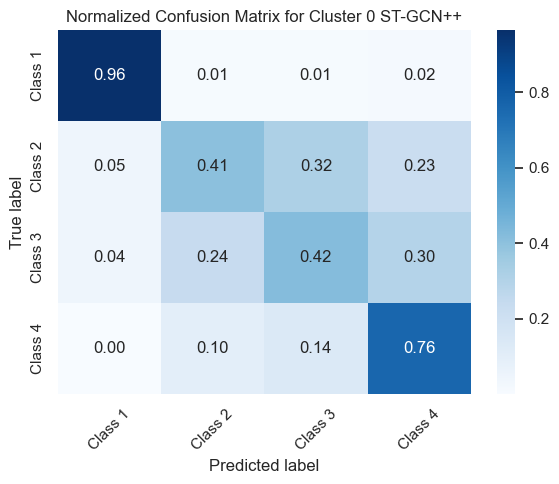

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）

cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=custom_labels, yticklabels=custom_labels,
            linewidths=0, linecolor='white')  # <-- 關鍵：linewidths=0
plt.title("Normalized Confusion Matrix for Cluster 0 ST-GCN++")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

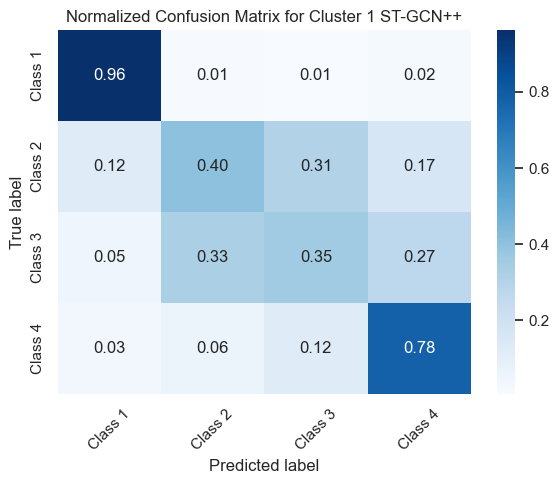

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S9raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=custom_labels, yticklabels=custom_labels,
            linewidths=0, linecolor='white')  # <-- 關鍵：linewidths=0
plt.title("Normalized Confusion Matrix for Cluster 1 ST-GCN++")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

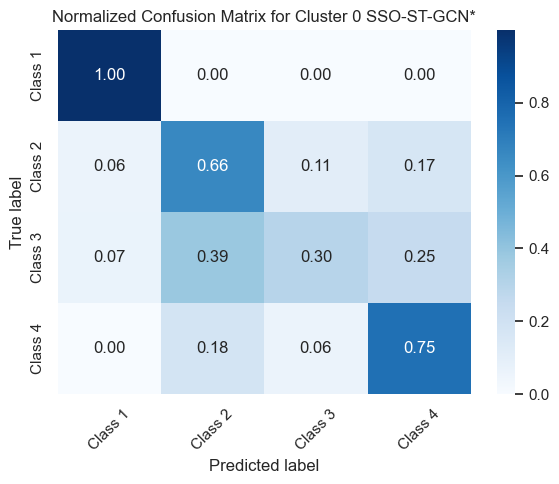

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=custom_labels, yticklabels=custom_labels,
            linewidths=0, linecolor='white')  # <-- 關鍵：linewidths=0
plt.title("Normalized Confusion Matrix for Cluster 0 SSO-ST-GCN*")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

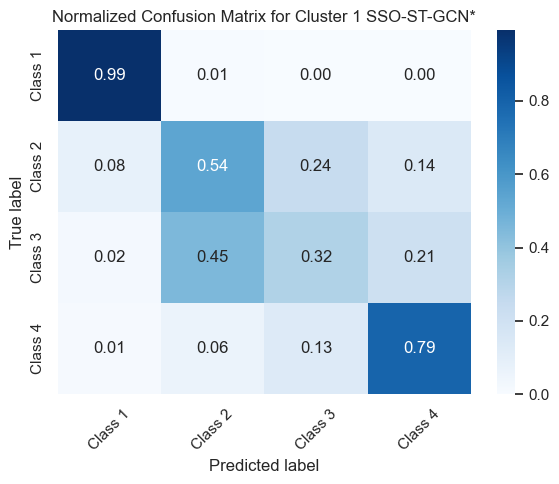

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s9_df = final_df[final_df["source"] == "S9"]

# 檢查是否包含必要欄位
if "label" not in s9_df.columns or "pred" not in s9_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s9_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s9_df["label"], s9_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=custom_labels, yticklabels=custom_labels,
            linewidths=0, linecolor='white')  # <-- 關鍵：linewidths=0
plt.title("Normalized Confusion Matrix for Cluster 1 SSO-ST-GCN*")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Params vs. Acc.

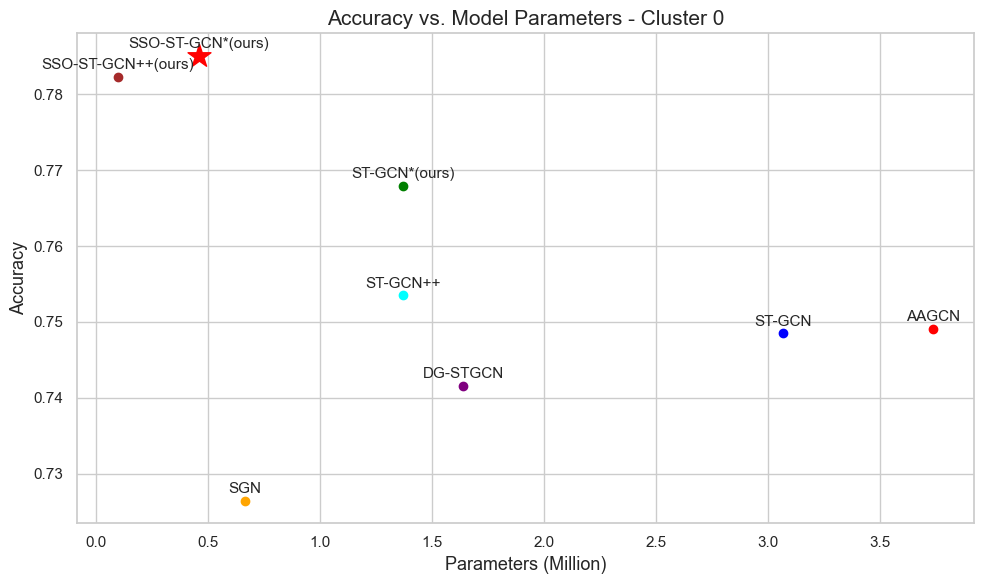

In [18]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.726389, 0.748519, 0.749097, 0.741551, 0.753495,
        0.767917, 0.782338, 0.785116
    ],
    'Params': [
        0.66574, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.09578, 0.457676
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 0', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

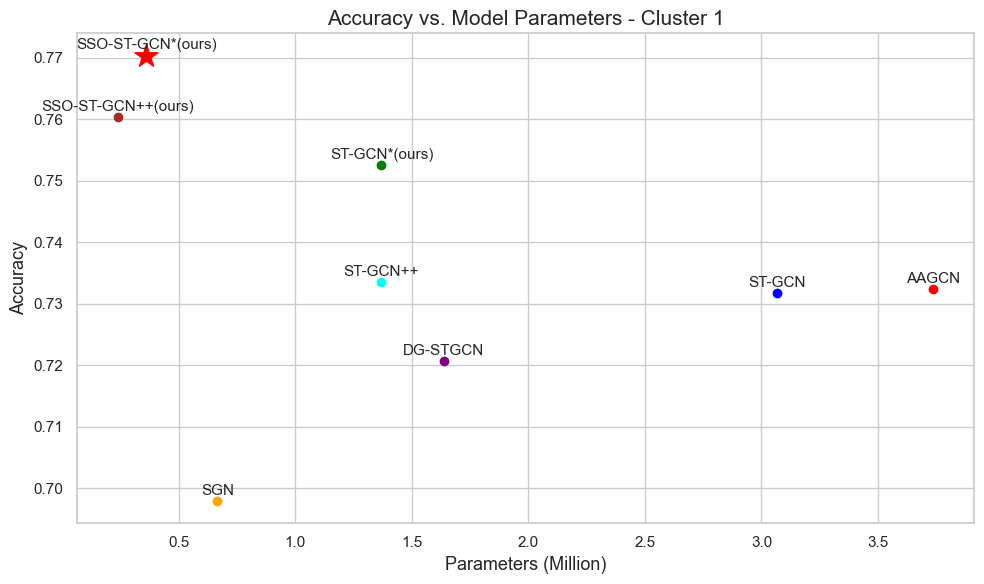

In [19]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.697940, 0.731690, 0.732454, 0.720741, 0.733565,
        0.752500, 0.760370, 0.770347
    ],
    'Params': [
        0.665740, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.237436, 0.360742
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 1', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()